In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from functools import partial

from mc_pricer.mc_asian import mc_asian
from mc_pricer.mc_euro import mc_european, black_scholes_price
from mc_pricer.mc_greeks import mc_delta, mc_gamma

European options

In [4]:
S0, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.2
option_type = "call"
seed = 42

bs = black_scholes_price(S0, K, T, r, sigma, option_type)

mc = partial(
    mc_european,S0, K, T, r, sigma,
    option_type=option_type)

def run_pair(n_samples, seed):
    plain = mc(n_samples=n_samples, method="plain", seed=seed)
    anti  = mc(n_samples=n_samples, method="antithetic", seed=seed)
    return plain, anti

In [ ]:
# plain vs antithetic
( p_plain, se_plain, ci_plain ), ( p_anti, se_anti, ci_anti ) = run_pair(100_000, seed)

print(f"Black-Scholes: {bs:.6f}")
print(f"Plain MC     : {p_plain:.6f} | SE={se_plain:.6f} | CI95=({ci_plain[0]:.6f}, {ci_plain[1]:.6f})")
print(f"Antithetic MC: {p_anti:.6f} | SE={se_anti:.6f} | CI95=({ci_anti[0]:.6f}, {ci_anti[1]:.6f})")


Black-Scholes: 10.450584
Plain MC     : 10.463414 | SE=0.033118 | CI95=(10.398503, 10.528324)
Antithetic MC: 10.471998 | SE=0.016536 | CI95=(10.439586, 10.504409)


Estimator variance (plain)      : 0.009253
Estimator variance (antithetic) : 0.003011
Variance reduction factor       : 3.07x


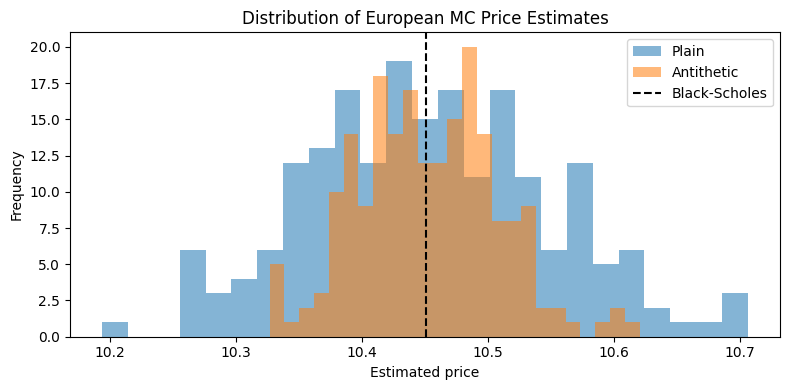

In [6]:
# Variance reduction
n_rep, n_samples, base_seed = 200, 20_000, 10_000
pairs = [run_pair(n_samples, base_seed + i) for i in range(n_rep)]

plain_estimates = np.array([p[0][0] for p in pairs])  # first tuple, price
anti_estimates  = np.array([p[1][0] for p in pairs])  # second tuple, price

var_plain = np.var(plain_estimates, ddof=1)
var_anti = np.var(anti_estimates, ddof=1)
vr_factor = var_plain / var_anti

print(f"Estimator variance (plain)      : {var_plain:.6f}")
print(f"Estimator variance (antithetic) : {var_anti:.6f}")
print(f"Variance reduction factor       : {vr_factor:.2f}x")

plt.figure(figsize=(8, 4))
plt.hist(plain_estimates, bins=25, alpha=0.55, label="Plain")
plt.hist(anti_estimates, bins=25, alpha=0.55, label="Antithetic")
plt.axvline(bs, color="black", linestyle="--", label="Black-Scholes")
plt.title("Distribution of European MC Price Estimates")
plt.xlabel("Estimated price")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

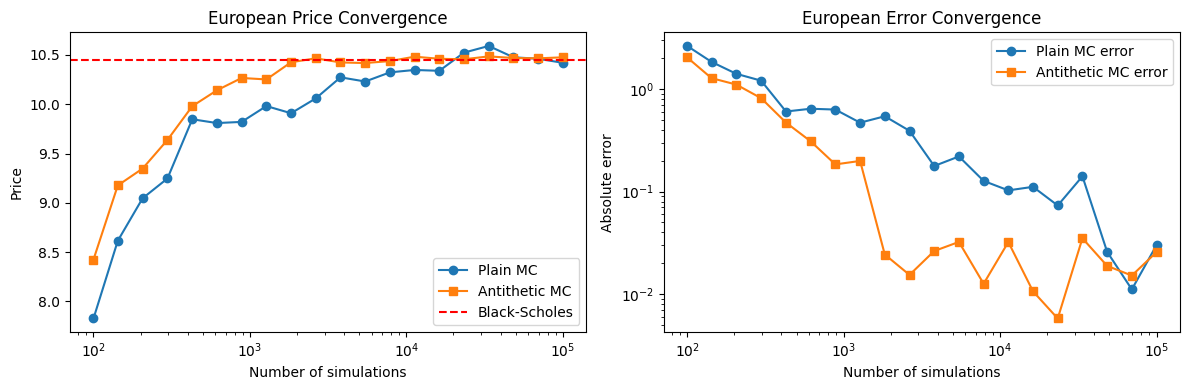

Estimated slope (plain): -0.664
Estimated slope (anti) : -0.751


In [7]:
# Convergence plots
N_values = np.logspace(2, 5, 20, dtype=int)
pairs_N = [run_pair(int(N), seed) for N in N_values]

plain_prices = np.array([p[0][0] for p in pairs_N])
anti_prices  = np.array([p[1][0] for p in pairs_N])

plain_err = np.abs(plain_prices - bs)
anti_err  = np.abs(anti_prices - bs)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(N_values, plain_prices, marker="o", label="Plain MC")
ax[0].plot(N_values, anti_prices, marker="s", label="Antithetic MC")
ax[0].axhline(bs, linestyle="--", color="red", label="Black-Scholes")
ax[0].set_xscale("log")
ax[0].set_title("European Price Convergence")
ax[0].set_xlabel("Number of simulations")
ax[0].set_ylabel("Price")
ax[0].legend()

ax[1].plot(N_values, plain_err, marker="o", label="Plain MC error")
ax[1].plot(N_values, anti_err, marker="s", label="Antithetic MC error")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title("European Error Convergence")
ax[1].set_xlabel("Number of simulations")
ax[1].set_ylabel("Absolute error")
ax[1].legend()

plt.tight_layout()
plt.show()

# slope check
eps = 1e-16
slope_plain, _ = np.polyfit(np.log(N_values), np.log(np.maximum(plain_err, eps)), 1)
slope_anti, _ = np.polyfit(np.log(N_values), np.log(np.maximum(anti_err, eps)), 1)
print(f"Estimated slope (plain): {slope_plain:.3f}")
print(f"Estimated slope (anti) : {slope_anti:.3f}")

In [ ]:
d_eur, d_eur_se, d_eur_ci = mc_delta(mc_european, S0, K, T, r, sigma, option_type=option_type, n_samples=100_000, n_rep=20)
g_eur, g_eur_se, g_eur_ci = mc_gamma(mc_european, S0, K, T, r, sigma, option_type=option_type, n_samples=100_000, seed=42, n_rep=20)

print(f"European Delta MC: {d_eur:.2f} | SE: {d_eur_se:.2f} | CI: {d_eur_ci[0]:.2f}, {d_eur_ci[1]:.2f}")
print(f"European Gamma MC: {g_eur:.2f} | SE: {g_eur_se:.2f} | CI: {g_eur_ci[0]:.2f},{g_eur_ci[1]:.2f}")


European delta MC: 0.64
European gamma MC: 0.02


Asian options

In [9]:
S0, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.2
option_type = "call"
averaging = "arithmetic"   # or "geometric"
include_S0 = False
n_steps = 252
seed = 42

asian = partial(
    mc_asian, S0, K, T, r, sigma,
    n_steps=n_steps, option_type=option_type,
    averaging=averaging,include_S0=include_S0,
)

def run_pair(n_samples, seed):
    plain = asian(n_samples=n_samples, method="plain", seed=seed)
    anti  = asian(n_samples=n_samples, method="antithetic", seed=seed)
    return plain, anti


In [10]:
# Plain vs antithetic
( p_plain, se_plain, ci_plain ), ( p_anti, se_anti, ci_anti ) = run_pair(200_000, seed)

print(f"Asian plain MC     : {p_plain:.6f} | SE={se_plain:.6f} | CI95=({ci_plain[0]:.6f}, {ci_plain[1]:.6f})")
print(f"Asian antithetic MC: {p_anti:.6f} | SE={se_anti:.6f} | CI95=({ci_anti[0]:.6f}, {ci_anti[1]:.6f})")


Asian plain MC     : 5.804757 | SE=0.017935 | CI95=(5.769605, 5.839910)
Asian antithetic MC: 5.794212 | SE=0.008781 | CI95=(5.777001, 5.811422)


Estimator variance (plain)            : 0.002908
Estimator variance (antithetic)       : 0.000698
Estimator variance (control variate)  : 0.000002
Variance reduction (plain -> anti)    : 4.17x
Variance reduction (plain -> CV)      : 1282.95x


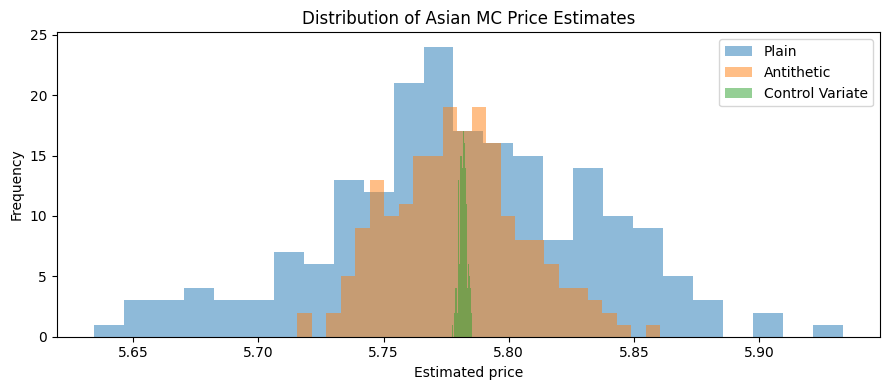

In [11]:
# Variance reduction: plain vs antithetic vs control variate
n_rep, n_samples, base_seed = 200, 20_000, 10_000

def run_triplet(n_samples, seed):
    kwargs = dict(
        S0=S0, K=K, T=T, r=r, sigma=sigma,
        n_steps=252, n_samples=n_samples,
        option_type="call", averaging="arithmetic",
        include_S0=False, seed=seed
    )
    plain = mc_asian(method="plain", **kwargs)
    anti  = mc_asian(method="antithetic", **kwargs)
    cv    = mc_asian(method="control_variate", **kwargs)  # requires CV method in mc_asian
    return plain, anti, cv

triples = [run_triplet(n_samples, base_seed + i) for i in range(n_rep)]

plain_estimates = np.array([x[0][0] for x in triples])  # price
anti_estimates  = np.array([x[1][0] for x in triples])  # price
cv_estimates    = np.array([x[2][0] for x in triples])  # price

var_plain = np.var(plain_estimates, ddof=1)
var_anti  = np.var(anti_estimates, ddof=1)
var_cv    = np.var(cv_estimates, ddof=1)

vr_plain_to_anti = var_plain / var_anti
vr_plain_to_cv   = var_plain / var_cv

print(f"Estimator variance (plain)            : {var_plain:.6f}")
print(f"Estimator variance (antithetic)       : {var_anti:.6f}")
print(f"Estimator variance (control variate)  : {var_cv:.6f}")
print(f"Variance reduction (plain -> anti)    : {vr_plain_to_anti:.2f}x")
print(f"Variance reduction (plain -> CV)      : {vr_plain_to_cv:.2f}x")

plt.figure(figsize=(9, 4))
plt.hist(plain_estimates, bins=25, alpha=0.50, label="Plain")
plt.hist(anti_estimates,  bins=25, alpha=0.50, label="Antithetic")
plt.hist(cv_estimates,    bins=25, alpha=0.50, label="Control Variate")
plt.title("Distribution of Asian MC Price Estimates")
plt.xlabel("Estimated price")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


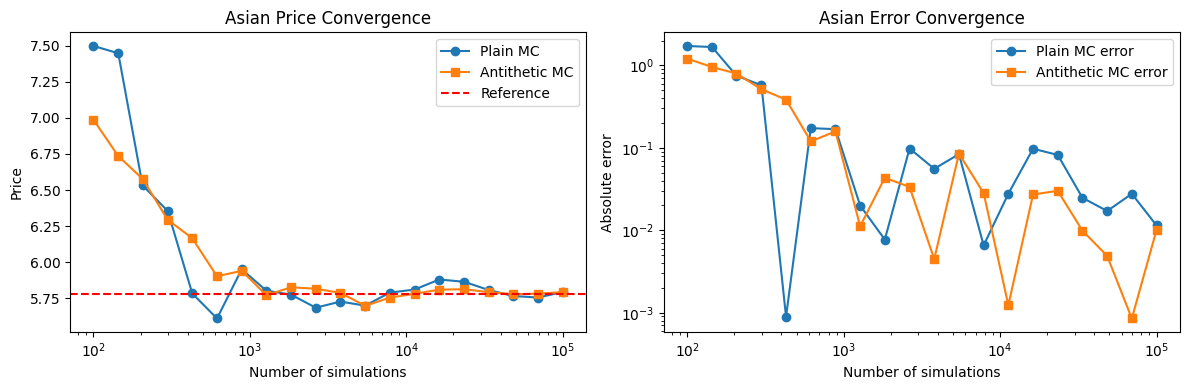

Estimated slope (plain): -0.475
Estimated slope (anti) : -0.845


In [ ]:
# Convergence (used high-N antithetic as reference for Asian arithmetic here)
ref_price, _, _ = asian(n_samples=2_000_000, method="control_variate", seed=999)

N_values = np.logspace(2, 5, 20, dtype=int)
N_values = N_values + (N_values % 2)  # force even for antithetic

pairs_N = [run_pair(int(N), seed) for N in N_values]
plain_prices = np.array([x[0][0] for x in pairs_N])
anti_prices  = np.array([x[1][0] for x in pairs_N])

plain_err = np.abs(plain_prices - ref_price)
anti_err  = np.abs(anti_prices - ref_price)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(N_values, plain_prices, marker="o", label="Plain MC")
ax[0].plot(N_values, anti_prices, marker="s", label="Control Variate MC")
ax[0].axhline(ref_price, linestyle="--", color="red", label="Reference")
ax[0].set_xscale("log")
ax[0].set_title("Asian Price Convergence")
ax[0].set_xlabel("Number of simulations")
ax[0].set_ylabel("Price")
ax[0].legend()

ax[1].plot(N_values, plain_err, marker="o", label="Plain MC error")
ax[1].plot(N_values, anti_err, marker="s", label="Control Variate MC error")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title("Asian Error Convergence")
ax[1].set_xlabel("Number of simulations")
ax[1].set_ylabel("Absolute error")
ax[1].legend()

plt.tight_layout()
plt.show()

# slope check 
eps = 1e-16
slope_plain, _ = np.polyfit(np.log(N_values), np.log(np.maximum(plain_err, eps)), 1)
slope_anti, _ = np.polyfit(np.log(N_values), np.log(np.maximum(anti_err, eps)), 1)
print(f"Estimated slope (plain): {slope_plain:.3f}")
print(f"Estimated slope (anti) : {slope_anti:.3f}")

In [ ]:
d_as, d_as_se, d_as_ci = mc_delta(mc_asian, S0, K, T, r, sigma, bump_rel=1e-2, option_type=option_type, 
                                  n_steps=252, n_samples=100_000, seed = 42, n_rep=20)
g_as, g_as_se, g_as_ci = mc_gamma(mc_asian, S0, K, T, r, sigma, bump_rel=1e-2, option_type=option_type, 
                                  n_steps=252, n_samples=100_000, seed=42, n_rep=20)

print(f"Asian Delta MC: {d_as:.2f} | SE: {d_as_se:.2f} | CI: {d_as_ci[0]:.2f}, {d_as_ci[1]:.2f}")
print(f"Asian Gamma MC: {g_as:.2f} | SE: {g_as_se:.2f} | CI: {g_as_ci[0]:.2f},{g_as_ci[1]:.2f}")


Asian Delta MC: 0.59
Asian Gamma MC: 0.03
